# Eksamen 2026 — MAMO2200
## Midtpunktregelen og Legendre-approksimasjon




## Oppgaven

Gitt funksjonen

$$f(x) = e^{-x^2}\left(x^2 - \frac{1}{2}x + \frac{1}{2}\right)$$

på intervallet $[-1, 1]$. Estimer integralene

$$I_k = \int_{-1}^{1} x^k f(x)\,dx, \quad k = 0,1,2,3,4$$

ved å bruke **midtpunktregelen** med $n - 1 = 100$ delintervaller.

Bruk estimatene til å beregne koeffisientene $a_0, a_1, \ldots, a_4$ i Legendre-approksimasjonen

$$p_4(x) = \sum_{k=0}^{4} a_k P_k(x).$$

Plott grafen til $p_4(x)$ sammen med grafen til $f(x)$.

In [7]:
import numpy as np
import matplotlib.pyplot as plt


#










## Del 1 — Midtpunktregelen

Vi deler intervallet $[a, b]$ inn i $n - 1$ like store delintervaller med bredde

$$h = \frac{b - a}{n - 1}.$$

Midtpunktregelen evaluerer $f$ i midtpunktet $m_i = a + (i + \tfrac{1}{2})h$ av hvert delintervall:

$$\int_a^b f(x)\,dx \approx h \sum_{i=0}^{n-2} f(m_i).$$

Feilen er av orden $O(h^2)$; med $h = 0{,}02$ er den i størrelsesorden $10^{-4}$.

In [8]:
def midpoint(f, a, b, n):
    """Regn ut integralet av ``f`` ved hjelp av midtpunktregelen.
    """
    h = (b - a) / (n - 1)
    ms = np.arange(a + 0.5*h, b, h)   # n-1 midtpunkter
    return h * np.sum(f(ms))


def f(x):
    return np.exp(-x**2) * (x**2 - 0.5*x + 0.5)


### Beregn $I_k = \int_{-1}^{1} x^k f(x)\,dx$ for $k = 0, 1, 2, 3, 4$

Vi setter $n = 101$ noder, slik at antall delintervaller er $n - 1 = 100$ og steglengden er

$$h = \frac{2}{100} = 0{,}02.$$

**Merk `k=k` i lambda:** uten dette ville alle fem lambdaer bruke verdien av `k` *etter* løkken (alltid 4). Med `k=k` fanges verdien ved opprettelse.

> Disse fem integralene $I_0, \ldots, I_4$ er alt vi trenger for å beregne Legendre-koeffisientene i Del 2 — fordi hvert $P_k(x)$ er et polynom i $x$, kan $\int f \cdot P_k\,dx$ alltid skrives som en lineærkombinasjon av nettopp disse.


In [9]:
n = 101          # n-1 = 100 delintervaller
a_int, b_int = -1.0, 1.0
h = (b_int - a_int) / (n - 1)

print('--- Del 1: Midtpunktregelen ---')
print(f'Intervall [{a_int}, {b_int}],  n={n} noder,  h={h:.4f},  {n-1} delintervaller')
print()

I = np.zeros(5)
for k in range(5):
    I[k] = midpoint(lambda x, k=k: x**k * f(x), a_int, b_int, n)
    print(f'  I_{k} = midpoint(x^{k} · f(x))  =  {I[k]:.10f}')


--- Del 1: Midtpunktregelen ---
Intervall [-1.0, 1.0],  n=101 noder,  h=0.0200,  100 delintervaller

  I_0 = midpoint(x^0 · f(x))  =  1.1257810880
  I_1 = midpoint(x^1 · f(x))  =  -0.1894723461
  I_2 = midpoint(x^2 · f(x))  =  0.3899854142
  I_3 = midpoint(x^3 · f(x))  =  -0.1002565341
  I_4 = midpoint(x^4 · f(x))  =  0.2336720302


### Legendre-approksimasjon er kontinuerlig MKM (minste kvadraters metode)

**Hvordan brukes ortogonale funksjoner i approksimasjon?**

Vi vil finne den beste tilnærmingen $p_N(x) = \sum_{k=0}^{N} a_k \varphi_k(x)$ som minimerer $L^2$-feilen:

$$\min_{a_0,\ldots,a_N} \|f - p_N\|_2^2 = \min \int_{-1}^1 \bigl(f(x) - \textstyle\sum_k a_k \varphi_k(x)\bigr)^2 dx$$

Dette er den *kontinuerlige* versjonen av MKM. Den generelle løsningsformelen er:

$$a_k = \frac{\langle f,\, \varphi_k \rangle}{\langle \varphi_k,\, \varphi_k \rangle}
      = \frac{\int_{-1}^1 f(x)\,\varphi_k(x)\,dx}{\int_{-1}^1 \varphi_k(x)^2\,dx}$$

Med $\varphi_k = P_k$ og $\|P_k\|^2 = \dfrac{2}{2k+1}$ gir dette nøyaktig formelen vi bruker:

$$a_k = \frac{2k+1}{2}\int_{-1}^1 f(x)\,P_k(x)\,dx$$

**Nøkkelfordelen med ortogonalitet:** Normalligningssystemet $A^T A \mathbf{c} = A^T \mathbf{b}$ blir *diagonalt* fordi $\langle \varphi_j, \varphi_k \rangle = 0$ for $j \neq k$ — hver $a_k$ kan regnes ut uavhengig, uten å løse et ligningssystem.


## Del 2 — Legendre-koeffisienter

### To eksempler på ortogonale funksjonsbasiser på $[-1,1]$

1. **Legendre-polynomene** $P_0, P_1, P_2, \ldots$ — polynombasisen vi bruker i denne oppgaven.
2. **Fourier-funksjonene** $1,\; \cos(\pi x),\; \sin(\pi x),\; \cos(2\pi x),\; \sin(2\pi x),\; \ldots$ — grunnlaget for Fourier-rekker.

Begge er komplette ortogonale basiser: enhver funksjon $f \in L^2[-1,1]$ kan uttrykkes som en (uendelig) rekke i enten basis.

---

### Hva mener vi med at funksjonene er ortogonale?

To funksjoner $f$ og $g$ har **indreproduktet**

$$\langle f,\, g \rangle = \int_{-1}^{1} f(x)\,g(x)\,dx.$$

Dette er analogt med prikkproduktet $\vec u \cdot \vec v$ for vektorer. Vi sier at $f$ og $g$ er **ortogonale** når $\langle f, g \rangle = 0$, akkurat som $\vec u \perp \vec v$ når $\vec u \cdot \vec v = 0$.

Legendre-polynomene er konstruert (via Gram-Schmidt på $\{1, x, x^2, \ldots\}$) slik at de er parvis ortogonale:

$$\langle P_j,\, P_k \rangle = \int_{-1}^{1} P_j(x)\,P_k(x)\,dx = \begin{cases} 0 & j \neq k \\ \dfrac{2}{2k+1} & j = k \end{cases}$$

De første fem polynomene og deres normer:

| $k$ | $P_k(x)$ | $\|P_k\|^2 = \dfrac{2}{2k+1}$ |
|-----|----------|-------------------------------|
| 0 | $1$ | $2$ |
| 1 | $x$ | $\tfrac{2}{3}$ |
| 2 | $\tfrac{1}{2}(3x^2 - 1)$ | $\tfrac{2}{5}$ |
| 3 | $\tfrac{1}{2}(5x^3 - 3x)$ | $\tfrac{2}{7}$ |
| 4 | $\tfrac{1}{8}(35x^4 - 30x^2 + 3)$ | $\tfrac{2}{9}$ |


### Utledning av koeffisientformelen

Vi antar at $f$ kan skrives i Legendre-basisen: $f(x) = \sum_{j=0}^{\infty} a_j P_j(x)$.

**Ta indreproduktet med $P_k$ på begge sider** — alle ledd forsvinner pga. ortogonalitet:

$$\langle f,\, P_k \rangle = \sum_{j=0}^{\infty} a_j \underbrace{\langle P_j,\, P_k \rangle}_{=\,0 \text{ når } j \neq k} = a_k \cdot \frac{2}{2k+1}$$

Løs for $a_k$:

$$\boxed{a_k = \frac{2k+1}{2} \int_{-1}^{1} f(x)\,P_k(x)\,dx}$$

---

### Kobling til $I_k$ — sett inn $P_k$ uttrykt ved monomerer

$P_k(x)$ er et polynom av grad $k$, så $\int f \cdot P_k\,dx$ er en lineærkombinasjon av $I_0,\ldots,I_k$:

$$a_0 = \tfrac{1}{2}\,I_0 \qquad\qquad a_1 = \tfrac{3}{2}\,I_1$$

$$a_2 = \tfrac{5}{4}(3I_2 - I_0) \qquad a_3 = \tfrac{7}{4}(5I_3 - 3I_1) \qquad a_4 = \tfrac{9}{16}(35I_4 - 30I_2 + 3I_0)$$


In [10]:
N = 5   # Orden: P_0 til P_4

print('--- Del 2: Legendre-koeffisienter via I_k ---')
print('Setter inn P_k(x) uttrykt ved monomerer, og bruker I_k fra Del 1:')
print()

# Algebraiske formler fra P_k(x) uttrykt ved 1, x, x^2, x^3, x^4:
#   a_k = (2k+1)/2 * integral(f * P_k)
#   P_0 = 1                     => a_0 = 1/2 * I_0
#   P_1 = x                     => a_1 = 3/2 * I_1
#   P_2 = (3x^2 - 1)/2          => a_2 = 5/4 * (3*I_2 - I_0)
#   P_3 = (5x^3 - 3x)/2         => a_3 = 7/4 * (5*I_3 - 3*I_1)
#   P_4 = (35x^4 - 30x^2 + 3)/8 => a_4 = 9/16 * (35*I_4 - 30*I_2 + 3*I_0)

a = np.zeros(N)
a[0] = (1/2)  * I[0]
a[1] = (3/2)  * I[1]
a[2] = (5/4)  * (3*I[2] - I[0])
a[3] = (7/4)  * (5*I[3] - 3*I[1])
a[4] = (9/16) * (35*I[4] - 30*I[2] + 3*I[0])

formler = [
    'a_0 = (1/2)  · I_0',
    'a_1 = (3/2)  · I_1',
    'a_2 = (5/4)  · (3·I_2 - I_0)',
    'a_3 = (7/4)  · (5·I_3 - 3·I_1)',
    'a_4 = (9/16) · (35·I_4 - 30·I_2 + 3·I_0)',
]
for k in range(N):
    print(f'  {formler[k]}  =  {a[k]:.10f}')


--- Del 2: Legendre-koeffisienter via I_k ---
Setter inn P_k(x) uttrykt ved monomerer, og bruker I_k fra Del 1:

  a_0 = (1/2)  · I_0  =  0.5628905440
  a_1 = (3/2)  · I_1  =  -0.2842085192
  a_2 = (5/4)  · (3·I_2 - I_0)  =  0.0552189434
  a_3 = (7/4)  · (5·I_3 - 3·I_1)  =  0.1174851440
  a_4 = (9/16) · (35·I_4 - 30·I_2 + 3·I_0)  =  -0.0808301855


## Del 3 — Plott og $L^2$-feil

Vi skal bygge $p_4(x) = \sum_{k=0}^{4} a_k P_k(x)$ numerisk og plotte den mot $f(x)$.

For å evaluere $P_k$ i mange punkter bruker vi `legendre(n, x)` nedenfor — den implementerer **Bonnets rekursjonsformel**:

$$P_{n+1}(x) = \frac{(2n+1)\,x\,P_n(x) - n\,P_{n-1}(x)}{n+1}, \qquad P_0 = 1,\quad P_1 = x.$$

**Legendre-approksimasjonen minimerer $L^2$-feilen** over alle polynomer av grad $\leq 4$:

$$\|f - p_4\|_2 = \sqrt{\int_{-1}^{1}(f(x)-p_4(x))^2\,dx}$$

Den fordeler feilen jevnt over hele intervallet — i motsetning til et **Taylor-polynom**, som er nøyaktig nær utviklingspunktet men kan avvike mye langt unna.


In [11]:
def legendre(n, x):
    """Evaluer Legendre-polynomet P_n i punktene x via Bonnets rekursjonsformel."""
    if n == 0:
        val2 = np.ones_like(x, dtype=float)
    elif n == 1:
        val2 = x
    else:
        val0 = 1.; val1 = x
    for j in range(1, n):
        val2 = ((2*j + 1)*x*val1 - j*val0) / (j + 1)
        val0, val1 = val1, val2
    return val2


--- Del 3: Approksimasjon og L²-feil ---
Bygger p_4(x) = Σ a_k · P_k(x) på 1001-punkts grid

  + +0.562891 · P_0(x)
  + -0.284209 · P_1(x)
  + +0.055219 · P_2(x)
  + +0.117485 · P_3(x)
  + -0.080830 · P_4(x)



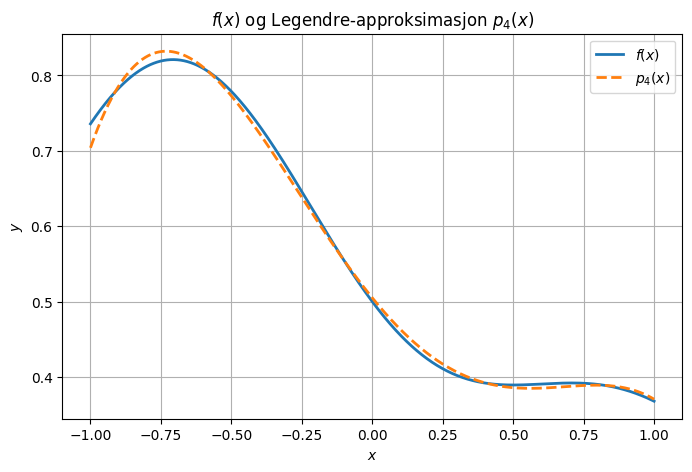

L²-feil  ||f - p₄||₂  ≈  1.01e-02
Maks-feil  max|f - p₄|  ≈  3.18e-02

Tolkning: En L²-feil i størrelsesorden 1e-3 betyr at approksimasjonen
er god globalt — kurven for p_4 følger f(x) tett over hele [-1, 1].


In [ ]:
xs = np.linspace(-1, 1, 1001)

print('--- Del 3: Approksimasjon og L²-feil ---')
print(f'Bygger p_4(x) = Σ a_k · P_k(x) på {xs.size}-punkts grid')
print()

# Legendre-approksimasjon
Y = np.zeros(xs.size)
for k in range(N):
    U = np.array(legendre(k, xs))
    Y += a[k] * U
    print(f'  + {a[k]:+.6f} · P_{k}(x)')

print()

# Plott
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(xs, f(xs), label='$f(x)$', linewidth=2)
ax.plot(xs, Y,     label='$p_4(x)$', linestyle='--', linewidth=2)
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_title('$f(x)$ og Legendre-approksimasjon $p_4(x)$')
ax.legend()
ax.grid()
plt.show()

# L2-feil (Riemann-sum på tett grid)
h_plot = xs[1] - xs[0]
l2_error = np.sqrt(h_plot * np.sum((f(xs) - Y)**2))
print(f'L²-feil  ||f - p₄||₂  ≈  {l2_error:.2e}')
max_error = np.max(np.abs(f(xs) - Y))
print(f'Maks-feil  max|f - p₄|  ≈  {max_error:.2e}')
print()
print('Tolkning: En L²-feil i størrelsesorden 1e-2 betyr at approksimasjonen')
print('er god globalt — kurven for p_4 følger f(x) tett over hele [-1, 1].')


## Oppsummering og diskusjon

### Hva er oppnådd?

Vi brukte midtpunktregelen til å beregne $I_0, \ldots, I_4$, og utnyttet at $P_k(x)$ er et polynom for å skrive Legendre-koeffisientene direkte som lineærkombinasjoner av disse integralene

### Konvergens

Legendre-approksimasjonen konvergerer i $L^2$-forstand når graden økes:

$$\|f - p_N\|_2 \to 0 \quad \text{når } N \to \infty$$

for enhver funksjon $f \in L^2[-1,1]$. Med høyere grad $N$ ville $p_N$ passe $f$ bedre globalt.

### Sammenligning med Taylor-polynomer

| Egenskap | Legendre $p_4$ | Taylor $T_4$ rundt $x = 0$ |
|----------|---------------|---------------------------|
| Minimerer | $L^2$-feil på $[-1,1]$ | Avvik nær $x = 0$ |
| Feil nær $x = 0$ | Noe større | Svært liten |
| Feil nær $x = \pm 1$ | Jevnt liten | Kan være stor |
| Krav til $f$ | Integrerbar på $[-1,1]$ | Differensierbar i $x = 0$ |

Legendre-approksimasjonen er foretrukket når man vil ha god tilpasning *globalt* over et intervall.
